# Analisis Customer Churn Telco


Notebook ini melakukan: data cleaning → exploratory data analysis (EDA) → perhitungan churn rate per segmen → 4 chart insight → draft memo insight.

## 0. Setup & Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

INPUT_FILE = "telco_churn.csv"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE)
print(f"Data awal: {df.shape[0]} baris, {df.shape[1]} kolom")
df.dtypes

Data awal: 7043 baris, 21 kolom


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning

`TotalCharges` sering terbaca sebagai teks karena ada baris dengan spasi kosong (biasanya pelanggan baru dengan tenure 0 bulan).

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_before = df["TotalCharges"].isna().sum()
print(f"Jumlah TotalCharges kosong/invalid: {missing_before}")

# Baris dengan TotalCharges kosong biasanya pelanggan baru (tenure=0) -> isi dengan 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Ubah kolom Churn jadi biner (1/0) untuk perhitungan lebih mudah
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})
df[["TotalCharges", "Churn", "ChurnFlag"]].head()

Jumlah TotalCharges kosong/invalid: 11


,TotalCharges,Churn,ChurnFlag
0,29.85,No,0
1,1889.50,No,0
2,108.15,Yes,1
3,1840.75,No,0
4,151.65,Yes,1


## 2. Exploratory Data Analysis (EDA)

In [5]:
overall_churn_rate = df["ChurnFlag"].mean() * 100
print(f"Churn rate keseluruhan: {overall_churn_rate:.1f}%")

Churn rate keseluruhan: 26.5%


### 2a. Churn rate per tipe kontrak

In [6]:
churn_by_contract = df.groupby("Contract")["ChurnFlag"].mean().sort_values(ascending=False) * 100
churn_by_contract

,ChurnFlag
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


### 2b. Churn rate per rentang tenure (lama berlangganan, dalam bulan)

In [7]:
bins = [0, 6, 12, 24, 48, 72]
labels = ["0-6 bln", "7-12 bln", "13-24 bln", "25-48 bln", "49-72 bln"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)
churn_by_tenure = df.groupby("TenureGroup", observed=True)["ChurnFlag"].mean() * 100
churn_by_tenure

,ChurnFlag
TenureGroup,
0-6 bln,52.937205
7-12 bln,35.886525
13-24 bln,28.710938
25-48 bln,20.388959
49-72 bln,9.513176


### 2c. Churn rate per metode pembayaran

In [8]:
churn_by_payment = df.groupby("PaymentMethod")["ChurnFlag"].mean().sort_values(ascending=False) * 100
churn_by_payment

,ChurnFlag
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


### 2d. Rata-rata biaya bulanan: churn vs tidak

In [9]:
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean()
avg_charges

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


## 3. Visualisasi

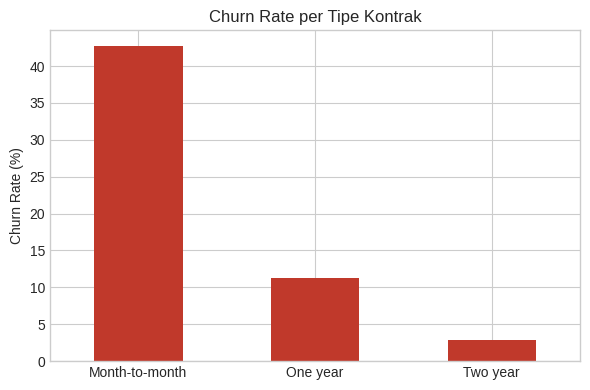

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract.plot(kind="bar", color="#c0392b", ax=ax)
ax.set_title("Churn Rate per Tipe Kontrak")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/1_churn_by_contract.png", dpi=150)
plt.show()

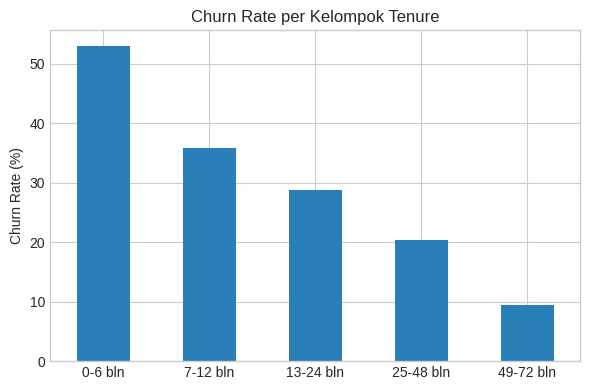

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_tenure.plot(kind="bar", color="#2980b9", ax=ax)
ax.set_title("Churn Rate per Kelompok Tenure")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/2_churn_by_tenure.png", dpi=150)
plt.show()

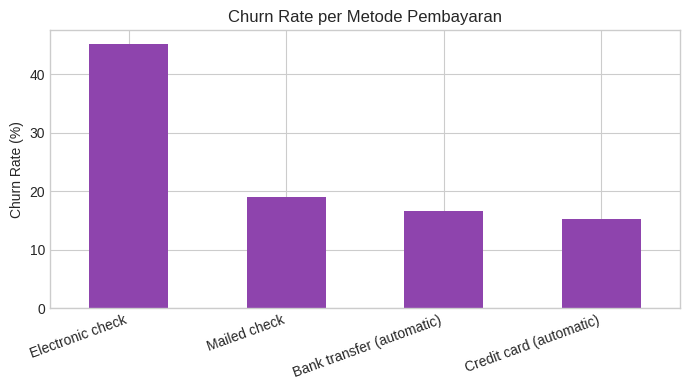

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
churn_by_payment.plot(kind="bar", color="#8e44ad", ax=ax)
ax.set_title("Churn Rate per Metode Pembayaran")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/3_churn_by_payment.png", dpi=150)
plt.show()

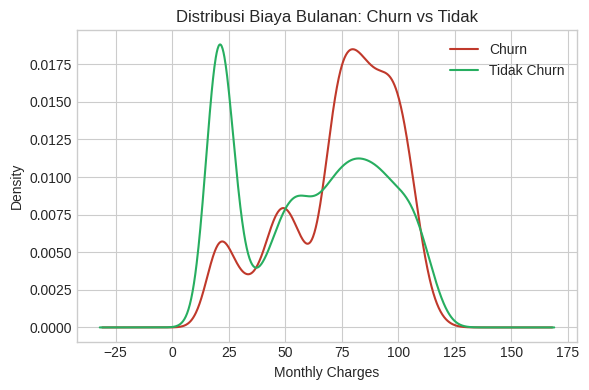

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
df[df["Churn"] == "Yes"]["MonthlyCharges"].plot(kind="density", ax=ax, label="Churn", color="#c0392b")
df[df["Churn"] == "No"]["MonthlyCharges"].plot(kind="density", ax=ax, label="Tidak Churn", color="#27ae60")
ax.set_title("Distribusi Biaya Bulanan: Churn vs Tidak")
ax.set_xlabel("Monthly Charges")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/4_monthly_charges_distribution.png", dpi=150)
plt.show()

## 4. Draft Memo Insight

Jalankan cell di bawah untuk menghasilkan draf memo otomatis dari angka-angka di atas. Perhalus kalimatnya dengan gaya Anda sendiri sebelum dipakai di README GitHub.

In [14]:
top_contract = churn_by_contract.index[0]
top_contract_rate = churn_by_contract.iloc[0]
lowest_tenure_rate = churn_by_tenure.iloc[0]
top_payment = churn_by_payment.index[0]
top_payment_rate = churn_by_payment.iloc[0]

memo = f"""
Churn rate keseluruhan pelanggan adalah {overall_churn_rate:.1f}%.

Temuan utama:
1. Kontrak "{top_contract}" punya churn rate tertinggi ({top_contract_rate:.1f}%),
   jauh di atas rata-rata keseluruhan.
2. Pelanggan di kelompok tenure "0-6 bln" churn paling tinggi ({lowest_tenure_rate:.1f}%)
   -> periode kritis retensi ada di awal berlangganan.
3. Metode pembayaran "{top_payment}" berasosiasi dengan churn rate tertinggi
   ({top_payment_rate:.1f}%).

Rekomendasi:
- Fokuskan program retensi pada pelanggan baru (<6 bulan) dengan kontrak
  bulanan, karena kombinasi ini paling berisiko churn.
- Pertimbangkan insentif migrasi ke kontrak tahunan pada 3 bulan pertama.
- Evaluasi pengalaman pembayaran untuk metode "{top_payment}" -
  kemungkinan ada friksi yang mendorong pelanggan keluar.

(Catatan: ini draft otomatis dari angka - perkuat dengan konteks bisnis
dan validasi asumsi sebelum dipakai sebagai keputusan nyata.)
"""
print(memo)

with open(f"{OUTPUT_DIR}/memo_insight.txt", "w") as f:
    f.write(memo)

print(f"Memo disimpan di '{OUTPUT_DIR}/memo_insight.txt'")


Churn rate keseluruhan pelanggan adalah 26.5%.

Temuan utama:
1. Kontrak "Month-to-month" punya churn rate tertinggi (42.7%),
   jauh di atas rata-rata keseluruhan.
2. Pelanggan di kelompok tenure "0-6 bln" churn paling tinggi (52.9%)
   -> periode kritis retensi ada di awal berlangganan.
3. Metode pembayaran "Electronic check" berasosiasi dengan churn rate tertinggi
   (45.3%).

Rekomendasi:
- Fokuskan program retensi pada pelanggan baru (<6 bulan) dengan kontrak
  bulanan, karena kombinasi ini paling berisiko churn.
- Pertimbangkan insentif migrasi ke kontrak tahunan pada 3 bulan pertama.
- Evaluasi pengalaman pembayaran untuk metode "Electronic check" -
  kemungkinan ada friksi yang mendorong pelanggan keluar.

(Catatan: ini draft otomatis dari angka - perkuat dengan konteks bisnis
dan validasi asumsi sebelum dipakai sebagai keputusan nyata.)

Memo disimpan di 'output/memo_insight.txt'
